## IMPORTS

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split


## DEFINITION OF VARIABLES

In [2]:
SOURCE_POLYMER_FILE = 'all_spectra.csv'
SOURCE_MICROPLASTIC_FILE = 'ambient_spectra.csv'

## Affine Coupling Layer

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =============================================================================
# Rational Quadratic Spline helpers (Neural Spline Flows, Durkan et al. 2019)
# =============================================================================

def rational_quadratic_spline_forward(x, widths, heights, derivatives, tail_bound=3.0):
    """
    Apply a rational-quadratic spline transform element-wise.
    x:           (batch, dim)  inputs in [-tail_bound, tail_bound]
    widths:      (batch, dim, K)  unnormalized bin widths
    heights:     (batch, dim, K)  unnormalized bin heights
    derivatives: (batch, dim, K+1) unnormalized knot derivatives
    Returns y, log_det_jacobian  (both shape (batch, dim))
    """
    K = widths.shape[-1]

    # --- softmax widths/heights so they tile [-B, B], softplus derivatives > 0 ---
    widths = F.softmax(widths, dim=-1) * 2 * tail_bound       # (batch, dim, K)
    heights = F.softmax(heights, dim=-1) * 2 * tail_bound     # (batch, dim, K)
    derivatives = F.softplus(derivatives)                       # (batch, dim, K+1)

    # Cumulative widths/heights → bin edges
    cumwidths = torch.cumsum(widths, dim=-1)                    # (batch, dim, K)
    cumwidths = F.pad(cumwidths, (1, 0), value=0.0)             # (batch, dim, K+1)
    cumwidths = cumwidths - tail_bound                          # shift to [-B, B]

    cumheights = torch.cumsum(heights, dim=-1)
    cumheights = F.pad(cumheights, (1, 0), value=0.0)
    cumheights = cumheights - tail_bound

    # Clamp inputs to the spline domain; outside → identity
    x_clamped = x.clamp(-tail_bound + 1e-6, tail_bound - 1e-6)

    # Find which bin each x falls into
    bin_idx = torch.searchsorted(cumwidths[..., 1:], x_clamped.unsqueeze(-1)).squeeze(-1)
    bin_idx = bin_idx.clamp(0, K - 1)

    # Gather per-bin parameters
    idx = bin_idx.unsqueeze(-1)  # (batch, dim, 1)
    w_k = widths.gather(-1, idx).squeeze(-1)          # bin width
    h_k = heights.gather(-1, idx).squeeze(-1)         # bin height
    d_k = derivatives.gather(-1, idx).squeeze(-1)     # left derivative
    d_k1 = derivatives.gather(-1, idx + 1).squeeze(-1) # right derivative
    cw_k = cumwidths.gather(-1, idx).squeeze(-1)      # left edge x
    ch_k = cumheights.gather(-1, idx).squeeze(-1)     # left edge y

    s_k = h_k / w_k  # slope of bin

    # Normalized position within the bin  ξ ∈ [0, 1]
    xi = (x_clamped - cw_k) / w_k
    xi = xi.clamp(1e-6, 1.0 - 1e-6)

    # Rational quadratic formula (Eq. 4 in the paper)
    numerator = h_k * (s_k * xi * xi + d_k * xi * (1 - xi))
    denominator = s_k + (d_k + d_k1 - 2 * s_k) * xi * (1 - xi)
    y = ch_k + numerator / denominator

    # Log-derivative (Eq. 5)
    deriv_numerator = s_k * s_k * (d_k1 * xi * xi + 2 * s_k * xi * (1 - xi) + d_k * (1 - xi) ** 2)
    log_det = torch.log(deriv_numerator + 1e-8) - 2 * torch.log(denominator.abs() + 1e-8)

    return y, log_det


def rational_quadratic_spline_inverse(y, widths, heights, derivatives, tail_bound=3.0):
    """
    Inverse of the rational-quadratic spline (bisection search).
    """
    K = widths.shape[-1]

    widths = F.softmax(widths, dim=-1) * 2 * tail_bound
    heights = F.softmax(heights, dim=-1) * 2 * tail_bound
    derivatives = F.softplus(derivatives)

    cumwidths = torch.cumsum(widths, dim=-1)
    cumwidths = F.pad(cumwidths, (1, 0), value=0.0) - tail_bound

    cumheights = torch.cumsum(heights, dim=-1)
    cumheights = F.pad(cumheights, (1, 0), value=0.0) - tail_bound

    y_clamped = y.clamp(-tail_bound + 1e-6, tail_bound - 1e-6)

    bin_idx = torch.searchsorted(cumheights[..., 1:], y_clamped.unsqueeze(-1)).squeeze(-1)
    bin_idx = bin_idx.clamp(0, K - 1)

    idx = bin_idx.unsqueeze(-1)
    w_k = widths.gather(-1, idx).squeeze(-1)
    h_k = heights.gather(-1, idx).squeeze(-1)
    d_k = derivatives.gather(-1, idx).squeeze(-1)
    d_k1 = derivatives.gather(-1, idx + 1).squeeze(-1)
    cw_k = cumwidths.gather(-1, idx).squeeze(-1)
    ch_k = cumheights.gather(-1, idx).squeeze(-1)

    s_k = h_k / w_k

    # Solve quadratic for xi given y (Appendix A of the paper)
    a = h_k * (s_k - d_k) + (y_clamped - ch_k) * (d_k + d_k1 - 2 * s_k)
    b = h_k * d_k - (y_clamped - ch_k) * (d_k + d_k1 - 2 * s_k)
    c = -s_k * (y_clamped - ch_k)

    discriminant = b * b - 4 * a * c
    discriminant = discriminant.clamp(min=0)
    xi = (2 * c) / (-b - torch.sqrt(discriminant + 1e-8))
    xi = xi.clamp(1e-6, 1.0 - 1e-6)

    x = cw_k + xi * w_k
    return x


# =============================================================================
# Spline Coupling Layer
# =============================================================================

class SplineParamNet(nn.Module):
    """MLP that predicts spline parameters (widths, heights, derivatives) from the conditioning half."""
    def __init__(self, in_dim, transform_dim, hidden_dim=128, n_bins=8, dropout=0.2):
        super().__init__()
        self.transform_dim = transform_dim
        self.n_bins = n_bins
        # Output: K widths + K heights + (K+1) derivatives per transformed dimension
        out_dim = transform_dim * (3 * n_bins + 1)
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )
        # Initialize near zero → spline starts close to identity
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        batch = x.shape[0]
        params = self.net(x)  # (batch, transform_dim * (3K+1))
        params = params.view(batch, self.transform_dim, 3 * self.n_bins + 1)
        widths = params[:, :, :self.n_bins]
        heights = params[:, :, self.n_bins:2*self.n_bins]
        derivatives = params[:, :, 2*self.n_bins:]
        return widths, heights, derivatives


class CouplingLayer(nn.Module):
    def __init__(self, dim, hidden_dim=128, n_bins=8, tail_bound=3.0, reverse=False):
        super().__init__()
        self.dim = dim
        self.reverse = reverse
        self.split_dim = (dim + 1) // 2
        self.transform_dim = dim - self.split_dim
        self.tail_bound = tail_bound

        # When reversed, swap which half conditions and which gets transformed
        cond_dim = self.transform_dim if reverse else self.split_dim
        trans_dim = self.split_dim if reverse else self.transform_dim

        self.param_net = SplineParamNet(
            in_dim=cond_dim,
            transform_dim=trans_dim,
            hidden_dim=hidden_dim,
            n_bins=n_bins
        )

    def forward(self, x):
        if self.reverse:
            # Second half conditions, first half gets transformed
            x_cond = x[:, self.split_dim:]
            x_trans = x[:, :self.split_dim]
        else:
            # First half conditions, second half gets transformed
            x_cond = x[:, :self.split_dim]
            x_trans = x[:, self.split_dim:]

        widths, heights, derivatives = self.param_net(x_cond)
        y_trans, log_det = rational_quadratic_spline_forward(
            x_trans, widths, heights, derivatives, self.tail_bound
        )
        log_det_sum = log_det.sum(dim=1)

        if self.reverse:
            return torch.cat([y_trans, x_cond], dim=1), log_det_sum
        else:
            return torch.cat([x_cond, y_trans], dim=1), log_det_sum

    def inverse(self, y):
        if self.reverse:
            y_trans = y[:, :self.split_dim]
            y_cond = y[:, self.split_dim:]
        else:
            y_cond = y[:, :self.split_dim]
            y_trans = y[:, self.split_dim:]

        widths, heights, derivatives = self.param_net(y_cond)
        x_trans = rational_quadratic_spline_inverse(
            y_trans, widths, heights, derivatives, self.tail_bound
        )

        if self.reverse:
            return torch.cat([x_trans, y_cond], dim=1)
        else:
            return torch.cat([y_cond, x_trans], dim=1)

In [4]:
class StandardGaussian:
    def __init__(self, dim):
        self.dim = dim
        self._log_norm = -0.5 * dim * np.log(2.0 * np.pi)

    def log_prob(self, z):
        return self._log_norm - 0.5 * (z * z).sum(dim=1)
    
    def sample(self, n_samples):
        return torch.randn(n_samples, self.dim)

In [5]:
class PermutationLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.register_buffer('permutation', torch.randperm(dim))
        self.register_buffer('inverse_permutation', torch.argsort(self.permutation))

    def forward(self, x):
        return x[:, self.permutation], torch.zeros(x.shape[0], device=x.device)
    
    def inverse(self, y):
        return y[:,self.inverse_permutation]
    

In [6]:
class ActNorm(nn.Module):
    """
    Activation Normalization (Kingma & Dhariwal, 2018 — Glow).
    Learned per-channel scale and bias with data-dependent initialization.
    On the first forward pass the parameters are set so that the output of
    the layer has zero mean and unit variance (per dimension).
    """
    def __init__(self, dim):
        super().__init__()
        self.log_scale = nn.Parameter(torch.zeros(1, dim))
        self.bias = nn.Parameter(torch.zeros(1, dim))
        self.register_buffer('initialized', torch.tensor(False))

    @torch.no_grad()
    def _data_dependent_init(self, x):
        """Initialize so that output has mean=0, std=1."""
        mean = x.mean(dim=0, keepdim=True)
        std = x.std(dim=0, keepdim=True) + 1e-6
        self.bias.data.copy_(-mean)
        self.log_scale.data.copy_(-torch.log(std))
        self.initialized.fill_(True)

    def forward(self, x):
        if not self.initialized:
            self._data_dependent_init(x)
        z = (x + self.bias) * torch.exp(self.log_scale)
        # log |det J| = sum of log_scale (same for every sample)
        log_det = self.log_scale.sum().expand(x.shape[0])
        return z, log_det

    def inverse(self, z):
        x = z * torch.exp(-self.log_scale) - self.bias
        return x

In [7]:
class NormalizingFlow(nn.Module):
    def __init__(self, dim, n_layers = 4, hidden_dim = 128, n_bins = 8, tail_bound = 3.0):
        super().__init__()
        self.dim = dim
        self.n_layers = n_layers
        self.base_dist = StandardGaussian(dim)
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            # ActNorm before each coupling layer
            self.layers.append(ActNorm(dim))
            # Alternate which half gets transformed each layer
            self.layers.append(CouplingLayer(
                dim, hidden_dim=hidden_dim, n_bins=n_bins,
                tail_bound=tail_bound, reverse=(i % 2 == 1)
            ))
            if i < n_layers - 1:
                self.layers.append(PermutationLayer(dim))

    def forward(self, x):

        z = x
        log_det_sum = torch.zeros(x.shape[0], device=x.device)

        for layer in self.layers:
            z, log_det = layer(z)
            log_det_sum += log_det

        log_prob_z = self.base_dist.log_prob(z)
        log_prob_x = log_prob_z + log_det_sum

        return log_prob_x
    
    def inverse(self, z):
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x)
        return x
    
    def sample(self, n_samples):
        z = self.base_dist.sample(n_samples)
        x = self.inverse(z)

        return x

In [8]:
def train_flow(model, data, n_epochs=100, batch_size=32, lr=1e-3,
               weight_decay=1e-5, clip_grad_norm=5.0, val_data=None,
               patience=15):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.01)

    n_batches = len(data) // batch_size
    losses = []
    val_losses = []

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in tqdm(range(n_epochs)):
        model.train()
        perm = torch.randperm(len(data))
        data_shuffled = data[perm]

        epoch_loss = 0

        for i in range(n_batches):
            batch = data_shuffled[i*batch_size:(i+1)*batch_size]
            
            optimizer.zero_grad()

            log_prob = model(batch)
            loss = -log_prob.mean()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
            optimizer.step()

            epoch_loss += loss.item()
        
        scheduler.step()
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)

        # Validation loss (for monitoring overfitting)
        if val_data is not None:
            model.eval()
            with torch.no_grad():
                val_log_prob = model(val_data)
                val_loss = -val_log_prob.mean().item()
            val_losses.append(val_loss)

            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch+1} (no val improvement for {patience} epochs)')
                break

        if (epoch + 1) % 10 == 0:
            msg = f'Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}'
            if val_data is not None:
                msg += f', Val Loss: {val_losses[-1]:.4f}'
            msg += f', LR: {scheduler.get_last_lr()[0]:.6f}'
            print(msg)

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'Restored best model (val loss: {best_val_loss:.4f})')

    return losses, val_losses

## Training

In [9]:
# Load data
df_polymer = pd.read_csv(SOURCE_POLYMER_FILE, index_col=0)
df_amb = pd.read_csv(SOURCE_MICROPLASTIC_FILE, index_col=0)
# Dropping singular samples from the polymer dataset to ensure stratified splitting works correctly
df_polymer = df_polymer[df_polymer['polymer'].map(df_polymer['polymer'].value_counts()) > 1]
df_train, df_polymer_test = train_test_split(df_polymer, test_size = 0.2, stratify = df_polymer['polymer'], random_state = 42)
df_test = pd.concat([df_polymer_test, df_amb], ignore_index=True)
feature_cols = [
    col for col in df_train.columns
    if col != 'polymer' and str(col) != '' and not str(col).startswith('Unnamed')
]
print(f"Training data (normal polymers): {df_train.shape[0]} samples")
print(f"Test data (abnormal microplastics): {df_test.shape[0]} samples")

Training data (normal polymers): 970 samples
Test data (abnormal microplastics): 298 samples


In [ ]:
# Prepare training data (normal)
normal_data = df_train[feature_cols].values

# ALTERNATIVE: Use RobustScaler if values are too extreme
scaler = StandardScaler()
normal_scaled = scaler.fit_transform(normal_data)

# PCA dimensionality reduction — keep 90% of the total variance
pca = PCA(n_components=0.90, svd_solver='full')
normal_reduced = pca.fit_transform(normal_scaled)
n_components = pca.n_components_
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(f"PCA: keeping {n_components} / {normal_scaled.shape[1]} components "
      f"({cumulative_variance[-1]*100:.1f}% variance retained)")

# ---- Train / Validation split (80/20 of normal training data) ----
n_val = int(len(normal_reduced) * 0.2)
perm = np.random.RandomState(42).permutation(len(normal_reduced))
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_tensor = torch.FloatTensor(normal_reduced[train_idx])
val_tensor   = torch.FloatTensor(normal_reduced[val_idx])

print(f"Train split: {len(train_tensor)} samples, Val split: {len(val_tensor)} samples")

# Initialize and train model
n_features = train_tensor.shape[1]
model = NormalizingFlow(dim=n_features, n_layers=4, hidden_dim=32, n_bins=4)
# model = NormalizingFlow(dim=n_features, n_layers=8, hidden_dim=32, n_bins=4)

print(f"\nTraining Normalizing Flow model (WITH STANDARD SCALER + PCA)...")
print(f"Reduced from {normal_scaled.shape[1]} → {n_features} features")
print(f"Feature 0 range: [{normal_data[:, 0].min():.2f}, {normal_data[:, 0].max():.2f}]")
losses, val_losses = train_flow(
    model, train_tensor, n_epochs=250, batch_size=64, lr=1e-4,
    weight_decay=1e-5, clip_grad_norm=5.0, val_data=val_tensor,
    patience=15
)

PCA: keeping 47 / 535 components (90.1% variance retained)
Train split: 776 samples, Val split: 194 samples

Training Normalizing Flow model (WITH STANDARD SCALER + PCA)...
Reduced from 535 → 47 features
Feature 0 range: [-3.05, 2.89]


  0%|          | 0/250 [00:00<?, ?it/s]/var/folders/91/j3k25b391lv5t2z7dsh5s1b00000gn/T/ipykernel_97966/3344578701.py:38: UserWarning: torch.searchsorted(): boundary tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous boundary tensor if possible. This message will only appear once per program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:40.)
  bin_idx = torch.searchsorted(cumwidths[..., 1:], x_clamped.unsqueeze(-1)).squeeze(-1)
  4%|▍         | 11/250 [00:01<00:24,  9.67it/s]

Epoch 10/250, Loss: 92.8106, Val Loss: 91.4178, LR: 0.000100


  8%|▊         | 21/250 [00:02<00:23,  9.78it/s]

Epoch 20/250, Loss: 87.6691, Val Loss: 86.5962, LR: 0.000098


...

Epoch 230/250, Loss: 69.4280, Val Loss: 70.0966, LR: 0.000003


 96%|█████████▋| 241/250 [00:27<00:01,  8.77it/s]

Epoch 240/250, Loss: 69.4966, Val Loss: 70.0782, LR: 0.000001


100%|██████████| 250/250 [00:28<00:00,  8.75it/s]

Epoch 250/250, Loss: 69.6664, Val Loss: 70.0665, LR: 0.000001
Restored best model (val loss: 70.0665)


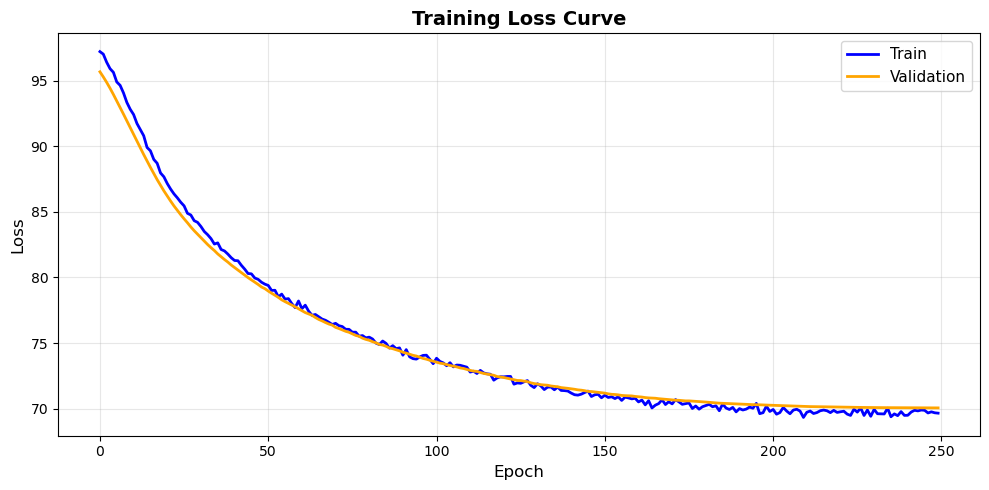

Final train loss: 69.6664
Final val loss:   70.0665
Train-Val gap:    0.4000  ✓ looks OK
Loss change (first to last epoch): 27.5362
⚠️  WARNING: Loss is increasing in recent epochs - model may not be converging well


In [11]:
# Plot training loss to diagnose convergence
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(losses, linewidth=2, color='blue', label='Train')
if val_losses:
    ax.plot(val_losses, linewidth=2, color='orange', label='Validation')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {losses[-1]:.4f}")
if val_losses:
    print(f"Final val loss:   {val_losses[-1]:.4f}")
    gap = val_losses[-1] - losses[-1]
    print(f"Train-Val gap:    {gap:.4f}  {'⚠️  overfitting' if gap > 5 else '✓ looks OK'}")
print(f"Loss change (first to last epoch): {losses[0] - losses[-1]:.4f}")
if losses[-1] > losses[-10]:
    print("⚠️  WARNING: Loss is increasing in recent epochs - model may not be converging well")
else:
    print("✓ Loss is decreasing - training appears stable")

ANOMALY DETECTION: Training Data Statistics
Training samples: 776
Mean log probability: -66.5168
Std log probability: 28.9533
Threshold (5th percentile): -112.2575
Threshold (anomaly score): 112.2575

CLASSIFYING TEST DATA

Total test samples: 298
  - Normal polymer samples (expected NORMAL): 243
  - Ambient microplastic samples (expected ANOMALY): 55

Predicted as ANOMALY: 37 (12.4%)
Predicted as NORMAL: 261 (87.6%)

CLASSIFICATION METRICS

Precision: 0.5946  (of predicted anomalies, how many are truly anomalous)
Recall:    0.4000  (of actual anomalies, how many were detected)
F1 Score:  0.4783

Full Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.94      0.90       243
     ANOMALY       0.59      0.40      0.48        55

    accuracy                           0.84       298
   macro avg       0.73      0.67      0.69       298
weighted avg       0.82      0.84      0.83       298

Confusion Matrix:
                  Predi

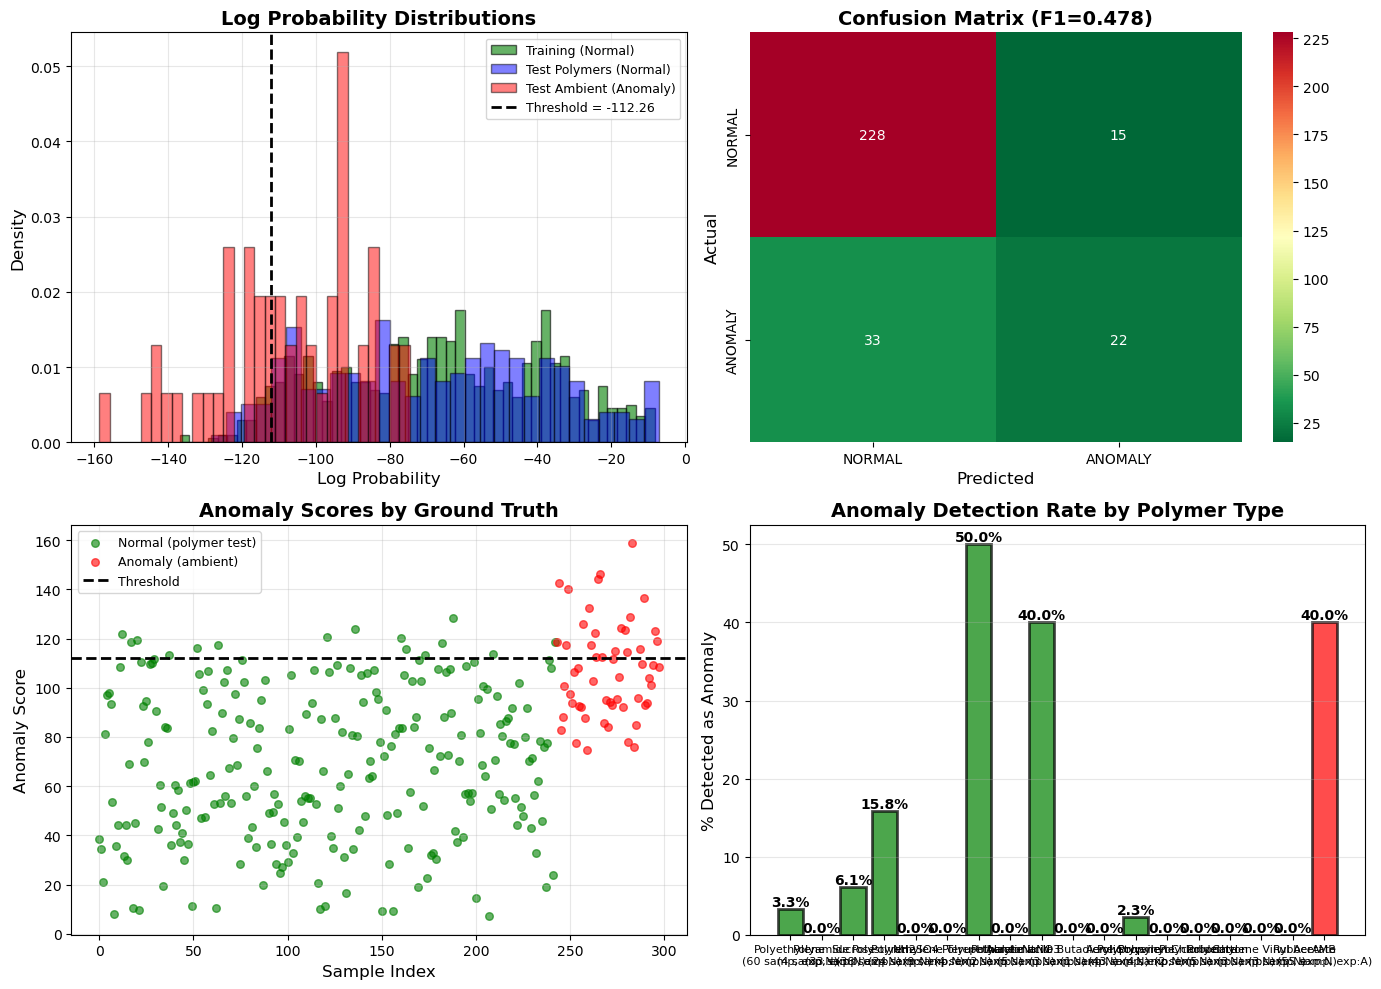


Results saved to: anomaly_detection_results.csv


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# ============================================================================
# EVALUATION: Classify test data as anomaly or normal
# Test set contains:
#   - df_polymer_test samples (NORMAL - known polymers held out from training)
#   - df_amb samples (ANOMALY - ambient microplastics)
# ============================================================================

model.eval()

# Step 1: Score TRAINING data to compute threshold
with torch.no_grad():
    train_log_probs = model(train_tensor).cpu().numpy()

# Compute threshold from training data statistics
THRESHOLD = 5
train_mean = train_log_probs.mean()
train_std = train_log_probs.std()
threshold_log_prob = np.percentile(train_log_probs, THRESHOLD)
threshold_anomaly_score = -threshold_log_prob

print(f"{'='*70}")
print(f"ANOMALY DETECTION: Training Data Statistics")
print(f"{'='*70}")
print(f"Training samples: {len(train_log_probs)}")
print(f"Mean log probability: {train_mean:.4f}")
print(f"Std log probability: {train_std:.4f}")
print(f"Threshold ({THRESHOLD}th percentile): {threshold_log_prob:.4f}")
print(f"Threshold (anomaly score): {threshold_anomaly_score:.4f}")

# Step 2: Score TEST data
print(f"\n{'='*70}")
print(f"CLASSIFYING TEST DATA")
print(f"{'='*70}\n")

with torch.no_grad():
    test_data = df_test[feature_cols].values
    if scaler is not None:
        test_scaled = scaler.transform(test_data)
    else:
        test_scaled = test_data.astype(np.float32)
    # Apply the same PCA projection used during training
    test_reduced = pca.transform(test_scaled)
    test_tensor = torch.FloatTensor(test_reduced)
    test_log_probs = model(test_tensor).cpu().numpy()

test_anomaly_scores = -test_log_probs
test_predictions = (test_anomaly_scores >= threshold_anomaly_score).astype(int)

# Step 3: Create ground truth labels
# Polymer test samples are NORMAL (0), ambient samples are ANOMALY (1)
n_polymer_test = len(df_polymer_test)
n_amb = len(df_amb)
ground_truth = np.array([0] * n_polymer_test + [1] * n_amb)

# Step 4: Create results dataframe
results_df = pd.DataFrame({
    'Sample_Index': range(len(test_log_probs)),
    'Log_Probability': test_log_probs.flatten(),
    'Anomaly_Score': test_anomaly_scores.flatten(),
    'Ground_Truth': ground_truth,
    'Predicted': test_predictions,
    'Ground_Truth_Label': ['ANOMALY' if g == 1 else 'NORMAL' for g in ground_truth],
    'Predicted_Label': ['ANOMALY' if p == 1 else 'NORMAL' for p in test_predictions]
})

if 'polymer' in df_test.columns:
    results_df['Polymer_Type'] = df_test['polymer'].values

# Display summary
anomaly_count = test_predictions.sum()
normal_count = len(test_predictions) - anomaly_count

print(f"Total test samples: {len(test_predictions)}")
print(f"  - Normal polymer samples (expected NORMAL): {n_polymer_test}")
print(f"  - Ambient microplastic samples (expected ANOMALY): {n_amb}")
print(f"\nPredicted as ANOMALY: {anomaly_count} ({100*anomaly_count/len(test_predictions):.1f}%)")
print(f"Predicted as NORMAL: {normal_count} ({100*normal_count/len(test_predictions):.1f}%)")

# Step 5: Compute proper metrics
print(f"\n{'='*70}")
print(f"CLASSIFICATION METRICS")
print(f"{'='*70}\n")

precision = precision_score(ground_truth, test_predictions, zero_division=0)
recall = recall_score(ground_truth, test_predictions, zero_division=0)
f1 = f1_score(ground_truth, test_predictions, zero_division=0)

print(f"Precision: {precision:.4f}  (of predicted anomalies, how many are truly anomalous)")
print(f"Recall:    {recall:.4f}  (of actual anomalies, how many were detected)")
print(f"F1 Score:  {f1:.4f}")

print(f"\nFull Classification Report:")
print(classification_report(ground_truth, test_predictions, target_names=['NORMAL', 'ANOMALY']))

cm = confusion_matrix(ground_truth, test_predictions)
print(f"Confusion Matrix:")
print(f"                  Predicted NORMAL  Predicted ANOMALY")
print(f"  Actual NORMAL   {cm[0,0]:>16}  {cm[0,1]:>17}")
print(f"  Actual ANOMALY  {cm[1,0]:>16}  {cm[1,1]:>17}")

# Step 6: Per-sample results
print(f"\n{'='*70}")
print(f"PER-SAMPLE RESULTS (first 20 samples)")
print(f"{'='*70}\n")
print(results_df.head(20).to_string(index=False))

if len(results_df) > 20:
    print(f"\n... and {len(results_df) - 20} more samples")

# Step 7: Per-polymer breakdown
if 'polymer' in df_test.columns:
    print(f"\n{'='*70}")
    print(f"RESULTS BY POLYMER TYPE")
    print(f"{'='*70}")
    
    for polymer in df_test['polymer'].unique():
        polymer_mask = results_df['Polymer_Type'] == polymer
        polymer_results = results_df[polymer_mask]
        
        anomaly_detected = polymer_results['Predicted'].sum()
        total = len(polymer_results)
        pct = 100 * anomaly_detected / total
        avg_anomaly_score = polymer_results['Anomaly_Score'].mean()
        expected = 'ANOMALY' if polymer_results['Ground_Truth'].iloc[0] == 1 else 'NORMAL'
        
        print(f"\n{polymer} (expected: {expected}):")
        print(f"  Total samples: {total}")
        print(f"  Detected as ANOMALY: {anomaly_detected}/{total} ({pct:.1f}%)")
        print(f"  Avg anomaly score: {avg_anomaly_score:.4f}")

# Step 8: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram of log probabilities
ax = axes[0, 0]
ax.hist(train_log_probs, bins=50, alpha=0.6, label='Training (Normal)', 
        color='green', edgecolor='black', density=True)
# Separate test into polymer_test (normal) and ambient (anomaly)
polymer_test_log_probs = test_log_probs[:n_polymer_test]
amb_log_probs = test_log_probs[n_polymer_test:]
ax.hist(polymer_test_log_probs, bins=30, alpha=0.5, label='Test Polymers (Normal)', 
        color='blue', edgecolor='black', density=True)
ax.hist(amb_log_probs, bins=30, alpha=0.5, label='Test Ambient (Anomaly)', 
        color='red', edgecolor='black', density=True)
ax.axvline(threshold_log_prob, color='black', linestyle='--', linewidth=2, 
          label=f'Threshold = {threshold_log_prob:.2f}')
ax.set_xlabel('Log Probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Log Probability Distributions', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 2: Confusion matrix heatmap
ax = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', 
            xticklabels=['NORMAL', 'ANOMALY'], yticklabels=['NORMAL', 'ANOMALY'], ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix (F1={f1:.3f})', fontsize=14, fontweight='bold')

# Plot 3: Anomaly scores scatter plot colored by ground truth
ax = axes[1, 0]
normal_mask = ground_truth == 0
anomaly_mask = ground_truth == 1
ax.scatter(np.where(normal_mask)[0], test_anomaly_scores[normal_mask], 
           c='green', alpha=0.6, s=30, label='Normal (polymer test)')
ax.scatter(np.where(anomaly_mask)[0], test_anomaly_scores[anomaly_mask], 
           c='red', alpha=0.6, s=30, label='Anomaly (ambient)')
ax.axhline(threshold_anomaly_score, color='black', linestyle='--', linewidth=2, label='Threshold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Anomaly Score', fontsize=12)
ax.set_title('Anomaly Scores by Ground Truth', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Plot 4: Detection rates by polymer type
if 'polymer' in df_test.columns:
    ax = axes[1, 1]
    polymer_types = results_df['Polymer_Type'].unique()
    detection_rates = []
    labels_by_polymer = []
    bar_colors = []
    
    for polymer in polymer_types:
        polymer_mask = results_df['Polymer_Type'] == polymer
        polymer_results = results_df[polymer_mask]
        total = len(polymer_results)
        anomaly_detected = polymer_results['Predicted'].sum()
        detection_rates.append(100 * anomaly_detected / total)
        expected = 'A' if polymer_results['Ground_Truth'].iloc[0] == 1 else 'N'
        labels_by_polymer.append(f"{polymer}\n({total} samp, exp:{expected})")
        bar_colors.append('red' if expected == 'A' else 'green')
    
    bars = ax.bar(range(len(polymer_types)), detection_rates, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_xticks(range(len(polymer_types)))
    ax.set_xticklabels(labels_by_polymer, fontsize=8)
    ax.set_ylabel('% Detected as Anomaly', fontsize=12)
    ax.set_title('Anomaly Detection Rate by Polymer Type', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, rate in zip(bars, detection_rates):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height, f'{rate:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Step 9: Save results to CSV
output_filename = 'anomaly_detection_results.csv'
results_df.to_csv(output_filename, index=False)

print(f"\nResults saved to: {output_filename}")

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Compute all metrics
accuracy = accuracy_score(ground_truth, test_predictions)
precision = precision_score(ground_truth, test_predictions, zero_division=0)
recall = recall_score(ground_truth, test_predictions, zero_division=0)
f1 = f1_score(ground_truth, test_predictions, zero_division=0)
# AUROC uses continuous anomaly scores (not binary predictions)
auroc = roc_auc_score(ground_truth, test_anomaly_scores)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUROC'],
    'Value': [accuracy, precision, recall, f1, auroc]
})
metrics_df['Value'] = metrics_df['Value'].map(lambda x: f"{x:.4f}")

print(f"{'='*40}")
print(f"  CLASSIFICATION METRICS SUMMARY")
print(f"{'='*40}")
print(metrics_df.to_string(index=False))
print(f"{'='*40}")
print(f"\nThreshold: {THRESHOLD}th percentile of training log-probs")
print(f"PCA components: {n_components} ({cumulative_variance[-1]*100:.1f}% variance)")

  CLASSIFICATION METRICS SUMMARY
   Metric  Value
 Accuracy 0.8389
Precision 0.5946
   Recall 0.4000
 F1 Score 0.4783
    AUROC 0.8445

Threshold: 5th percentile of training log-probs
PCA components: 47 (90.1% variance)


In [ ]:
print(1)


1


: 

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split as tts
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# KNN Baseline — EXACT replication of knn_hyperparameter_comparison_drop_1.ipynb
# Key differences from this notebook's flow pipeline:
#   1. Load CSVs with index_col=0 (reference does this)
#   2. Drop singular polymer samples (polymers with only 1 sample)
#   3. Stratified 80/20 split (stratify=y_all)
#   4. Column selection: all columns except 'polymer'
#   5. NO StandardScaler, NO SVD
# ============================================================================

# Reload data EXACTLY as the reference notebook does
all_spectra     = pd.read_csv(SOURCE_POLYMER_FILE, index_col=0)
ambient_spectra = pd.read_csv(SOURCE_MICROPLASTIC_FILE, index_col=0)

label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Drop singular samples (polymers with only 1 sample) so stratify works
all_spectra = all_spectra[all_spectra[label_col].map(all_spectra[label_col].value_counts()) > 1]

X_all     = all_spectra[wavelengths].values
y_all     = all_spectra[label_col].values
X_anomaly = ambient_spectra[wavelengths].values

# Stratified 80/20 split
X_train_knn, X_test_normal = tts(X_all, test_size=0.20, stratify=y_all, random_state=42)

# Test set = held-out normal + ambient anomalies
X_test_knn = np.vstack([X_test_normal, X_anomaly])
y_test = np.concatenate([np.zeros(len(X_test_normal)), np.ones(len(X_anomaly))])

print(f"Reference KNN replication:")
print(f"  All polymers:     {X_all.shape}")
print(f"  Train:            {X_train_knn.shape}")
print(f"  Test normal:      {X_test_normal.shape}")
print(f"  Test anomaly:     {X_anomaly.shape}")
print(f"  Total test:       {X_test_knn.shape}")
print(f"  Feature columns:  {len(wavelengths)}")

# Run all 6 configs
CONFIGS = [
    {'k': 3, 'metric': 'euclidean', 'threshold_pct': 95},
    {'k': 4, 'metric': 'euclidean', 'threshold_pct': 95},
    {'k': 5, 'metric': 'euclidean', 'threshold_pct': 95},
    {'k': 3, 'metric': 'cosine',    'threshold_pct': 95},
    {'k': 4, 'metric': 'cosine',    'threshold_pct': 95},
    {'k': 5, 'metric': 'cosine',    'threshold_pct': 95},
]

all_results = []

for cfg in CONFIGS:
    k, metric, thresh_pct = cfg['k'], cfg['metric'], cfg['threshold_pct']
    label = f"K={k}, {metric}, p{thresh_pct}"

    knn = NearestNeighbors(n_neighbors=k, metric=metric)
    knn.fit(X_train_knn)

    train_distances, _ = knn.kneighbors(X_train_knn)
    train_scores = train_distances.mean(axis=1)
    threshold = np.percentile(train_scores, thresh_pct)

    test_distances, _ = knn.kneighbors(X_test_knn)
    test_scores = test_distances.mean(axis=1)

    preds = (test_scores > threshold).astype(int)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds, zero_division=0)
    f1_  = f1_score(y_test, preds, zero_division=0)
    auc  = roc_auc_score(y_test, test_scores)
    cm   = confusion_matrix(y_test, preds)

    # Split test scores into normal vs anomaly for distribution plots
    scores_normal  = test_scores[y_test == 0]
    scores_anomaly = test_scores[y_test == 1]

    all_results.append({
        'label': label, 'k': k, 'metric': metric,
        'auc': auc, 'f1': f1_, 'precision': prec, 'recall': rec,
        'accuracy': acc, 'cm': cm, 'threshold': threshold,
        'scores_normal': scores_normal, 'scores_anomaly': scores_anomaly,
    })

    print(f"[{label}]  AUC={auc:.3f}  Recall={rec:.3f}  Precision={prec:.3f}  F1={f1_:.3f}  Threshold={threshold:.3f}")

# Summary table
summary = pd.DataFrame([{
    'Config': r['label'], 'AUC': f"{r['auc']:.3f}", 'Recall': f"{r['recall']:.3f}",
    'Precision': f"{r['precision']:.3f}", 'F1': f"{r['f1']:.3f}",
} for r in all_results]).sort_values('AUC', ascending=False)
print(f"\n{'='*60}")
print(summary.to_string(index=False))

# Plot confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, r in enumerate(all_results):
    ax = axes[i // 3, i % 3]
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['NORMAL', 'ANOMALY'], yticklabels=['NORMAL', 'ANOMALY'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f"{r['label']}\nF1={r['f1']:.3f}  AUC={r['auc']:.3f}", fontsize=10)
plt.suptitle('KNN Baseline — Exact Replication (Raw Features, No SVD)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Anomaly score distribution plots per KNN config
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, r in enumerate(all_results):
    ax = axes[i]

    # Plot score distributions
    ax.hist(r['scores_normal'],  bins=50, alpha=0.6, color='steelblue',  label='Normal')
    ax.hist(r['scores_anomaly'], bins=20, alpha=0.6, color='darkorange', label='Anomaly')

    # Draw decision threshold
    ax.axvline(r['threshold'], color='red', linestyle='--', linewidth=1.5,
               label=f'Threshold = {r["threshold"]:.2f}')

    ax.set_title(r['label'], fontsize=10)
    ax.set_xlabel('Anomaly Score (mean KNN distance)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('kNN — Anomaly Score Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()